# 🤖 Notebook 2: ML Ensemble Model
**Project:** Sports Image Classification  
**โมเดล:** Random Forest + SVM + XGBoost → VotingClassifier

---
### ⚠️ ต้องรัน Notebook 1 ให้เสร็จก่อน
Notebook นี้ใช้รูปจาก `datasets/processed/` ที่เตรียมไว้แล้ว

## ✅ Step 0: ติดตั้ง Libraries

In [1]:
# รันครั้งแรกครั้งเดียว
# !pip install scikit-learn xgboost opencv-python matplotlib seaborn scikit-image joblib

In [2]:
!c:\Users\std48.NAPAT\AppData\Local\Programs\Python\Python311\python.exe -m pip install numpy pandas matplotlib seaborn opencv-python scikit-learn
!c:\Users\std48.NAPAT\AppData\Local\Programs\Python\Python311\python.exe -m pip install scikit-image
!c:\Users\std48.NAPAT\AppData\Local\Programs\Python\Python311\python.exe -m pip install xgboost


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ------------------------------------- 101.7/101.7 MB 36.3 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## ✅ Step 1: Import & ตั้งค่า Path

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# ======================================================
# ⚠️ แก้ path ให้ตรงกับเครื่องของคุณ
# ======================================================
PROCESSED_PATH = Path(r'../datasets/processed')
MODELS_PATH    = Path(r'../models')
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# เลือก dataset ที่จะใช้ train ML (ใช้ dataset2 เพราะ 15 class เร็วกว่า)
# เปลี่ยนเป็น 'dataset1' ถ้าอยากใช้ 100 class
DATASET_NAME   = 'dataset2'
DATASET_PATH   = PROCESSED_PATH / DATASET_NAME
LABEL_MAP_PATH = PROCESSED_PATH / f'{DATASET_NAME}_label_map.json'

print('Paths set!')
print(f'Dataset  : {DATASET_PATH}')
print(f'Label map: {LABEL_MAP_PATH}')

Paths set!
Dataset  : ..\datasets\processed\dataset2
Label map: ..\datasets\processed\dataset2_label_map.json


## ✅ Step 2: โหลด Label Map

In [4]:
with open(LABEL_MAP_PATH) as f:
    label_map = json.load(f)  # {class_name: index}

idx_to_class = {v: k for k, v in label_map.items()}  # {index: class_name}
NUM_CLASSES   = len(label_map)

print(f'จำนวน class: {NUM_CLASSES}')
print(f'ตัวอย่าง: {dict(list(label_map.items())[:5])}')

จำนวน class: 15
ตัวอย่าง: {'american_football': 0, 'baseball': 1, 'basketball': 2, 'billiard_ball': 3, 'bowling_ball': 4}


## ✅ Step 3: ฟังก์ชันดึง HOG Features

**HOG (Histogram of Oriented Gradients)** คือการแปลงรูปภาพให้เป็น vector ตัวเลข  
โดยจับ pattern ของขอบ (edge) และทิศทางในรูป เหมาะมากสำหรับ ML แบบ traditional

In [5]:
def extract_hog(img_path, img_size=(128, 128)):
    """
    อ่านรูป → แปลงเป็น grayscale → ดึง HOG features
    return: numpy array (feature vector)
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.resize(img, img_size)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False
    )
    return features

# ทดสอบกับรูปแรกที่เจอ
test_img = next(DATASET_PATH.rglob('*.jpg'), None) or next(DATASET_PATH.rglob('*.png'), None)
if test_img:
    feat = extract_hog(test_img)
    print(f'HOG feature shape: {feat.shape}')  # ควรได้ประมาณ (8100,)
    print(f'ตัวอย่าง feature 5 ค่าแรก: {feat[:5].round(4)}')

HOG feature shape: (8100,)
ตัวอย่าง feature 5 ค่าแรก: [0.4493 0.     0.4493 0.     0.4387]


## ✅ Step 4: โหลดรูปและดึง Features (ใช้เวลาสักครู่)

In [6]:
def load_split(split_name, max_per_class=None):
    """
    โหลดรูปจาก split (train/valid/test) และดึง HOG features
    max_per_class: จำกัดรูปต่อ class (ใช้ลดเวลาถ้า dataset ใหญ่)
    """
    split_path = DATASET_PATH / split_name
    if not split_path.exists():
        print(f'ไม่พบ folder: {split_path}')
        return np.array([]), np.array([])

    X, y = [], []
    for cls_name, cls_idx in label_map.items():
        cls_path = split_path / cls_name
        if not cls_path.exists():
            continue
        imgs = list(cls_path.glob('*.jpg')) + list(cls_path.glob('*.png'))
        if max_per_class:
            imgs = imgs[:max_per_class]
        for img_path in imgs:
            feat = extract_hog(img_path)
            if feat is not None:
                X.append(feat)
                y.append(cls_idx)
    print(f'[{split_name}] โหลดแล้ว: {len(X)} รูป')
    return np.array(X), np.array(y)

print('กำลังโหลด train set ...')
X_train, y_train = load_split('train', max_per_class=150)

print('กำลังโหลด valid/test set ...')
X_val, y_val = load_split('valid', max_per_class=50)
if len(X_val) == 0:
    X_val, y_val = load_split('test', max_per_class=50)

print(f'\nX_train shape: {X_train.shape}')
print(f'X_val   shape: {X_val.shape}')

กำลังโหลด train set ...
[train] โหลดแล้ว: 2250 รูป
กำลังโหลด valid/test set ...
ไม่พบ folder: ..\datasets\processed\dataset2\valid
[test] โหลดแล้ว: 750 รูป

X_train shape: (2250, 8100)
X_val   shape: (750, 8100)


## ✅ Step 5: Normalize Features (StandardScaler)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print(f'X_train_scaled mean ≈ {X_train_scaled.mean():.4f} (ควรใกล้ 0)')
print(f'X_train_scaled std  ≈ {X_train_scaled.std():.4f}  (ควรใกล้ 1)')

X_train_scaled mean ≈ 0.0000 (ควรใกล้ 0)
X_train_scaled std  ≈ 1.0000  (ควรใกล้ 1)


## ✅ Step 6: Train โมเดลทั้ง 3

### ทฤษฎีสั้น ๆ
- **Random Forest** — สร้าง Decision Tree หลายต้น แล้ว vote ผลลัพธ์
- **SVM** — หาเส้นแบ่ง (hyperplane) ที่ดีที่สุดระหว่าง class
- **XGBoost** — สร้าง Tree แบบ Gradient Boosting ทีละต้น แก้ error ของต้นก่อนหน้า

In [8]:
print('Training Random Forest ...')
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
rf_acc = accuracy_score(y_val, rf.predict(X_val_scaled))
print(f'Random Forest Accuracy: {rf_acc*100:.2f}%')

Training Random Forest ...
Random Forest Accuracy: 28.40%


In [9]:
print('Training SVM ...')
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,   # ต้องเปิดเพื่อใช้ใน VotingClassifier แบบ soft
    random_state=42
)
svm.fit(X_train_scaled, y_train)
svm_acc = accuracy_score(y_val, svm.predict(X_val_scaled))
print(f'SVM Accuracy: {svm_acc*100:.2f}%')

Training SVM ...
SVM Accuracy: 33.60%


In [10]:
print('Training XGBoost ...')
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_scaled, y_train)
xgb_acc = accuracy_score(y_val, xgb.predict(X_val_scaled))
print(f'XGBoost Accuracy: {xgb_acc*100:.2f}%')

Training XGBoost ...
XGBoost Accuracy: 31.07%


## ✅ Step 7: รวม Ensemble ด้วย VotingClassifier

In [11]:
print('Training Voting Ensemble ...')
ensemble = VotingClassifier(
    estimators=[
        ('rf',  rf),
        ('svm', svm),
        ('xgb', xgb)
    ],
    voting='soft'  # ใช้ค่า probability เฉลี่ย (ดีกว่า hard voting)
)
ensemble.fit(X_train_scaled, y_train)
ens_pred  = ensemble.predict(X_val_scaled)
ens_acc   = accuracy_score(y_val, ens_pred)
print(f'Ensemble Accuracy: {ens_acc*100:.2f}%')

Training Voting Ensemble ...
Ensemble Accuracy: 34.13%


## ✅ Step 8: เปรียบเทียบผลทุกโมเดล

Model                  Accuracy
----------------------------------------
Random Forest            28.40%
SVM                      33.60%
XGBoost                  31.07%
Ensemble                 34.13% ← best


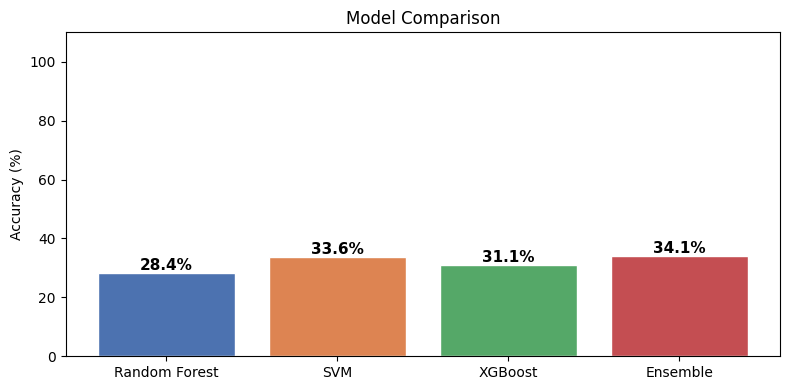

In [12]:
results = {
    'Random Forest': rf_acc,
    'SVM':           svm_acc,
    'XGBoost':       xgb_acc,
    'Ensemble':      ens_acc
}

# ตาราง
print('='*40)
print(f'{"Model":<20} {"Accuracy":>10}')
print('-'*40)
for model, acc in results.items():
    best = ' ← best' if acc == max(results.values()) else ''
    print(f'{model:<20} {acc*100:>9.2f}%{best}')
print('='*40)

# Bar chart
plt.figure(figsize=(8, 4))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
bars = plt.bar(results.keys(), [v*100 for v in results.values()], color=colors, edgecolor='white')
plt.ylim(0, 110)
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_PATH / 'ml_accuracy_comparison.png', dpi=120)
plt.show()

## ✅ Step 9: Classification Report + Confusion Matrix

In [13]:
# Classification Report
target_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print('Classification Report — Ensemble Model')
print('='*60)
print(classification_report(y_val, ens_pred, target_names=target_names))

Classification Report — Ensemble Model
                   precision    recall  f1-score   support

american_football       0.38      0.36      0.37        50
         baseball       0.38      0.28      0.32        50
       basketball       0.43      0.38      0.40        50
    billiard_ball       0.26      0.28      0.27        50
     bowling_ball       0.28      0.38      0.32        50
     cricket_ball       0.43      0.40      0.42        50
         football       0.50      0.48      0.49        50
        golf_ball       0.18      0.24      0.20        50
      hockey_ball       0.30      0.34      0.32        50
      hockey_puck       0.27      0.18      0.22        50
       rugby_ball       0.55      0.52      0.54        50
      shuttlecock       0.40      0.48      0.44        50
table_tennis_ball       0.29      0.44      0.35        50
      tennis_ball       0.29      0.10      0.15        50
       volleyball       0.25      0.26      0.26        50

         accura

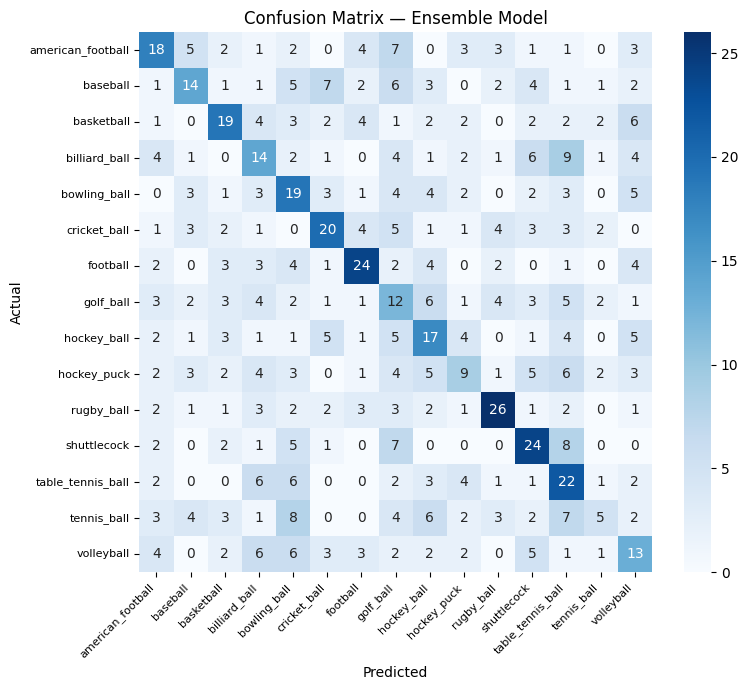

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_val, ens_pred)
plt.figure(figsize=(max(8, NUM_CLASSES//2), max(6, NUM_CLASSES//2)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix — Ensemble Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(PROCESSED_PATH / 'ml_confusion_matrix.png', dpi=120)
plt.show()

## ✅ Step 10: บันทึกโมเดลและ Scaler

In [15]:
# บันทึกโมเดลและ scaler ไว้ใช้กับ Streamlit
joblib.dump(ensemble, MODELS_PATH / 'ensemble_model.pkl')
joblib.dump(scaler,   MODELS_PATH / 'scaler.pkl')

# บันทึก label map ไว้ที่ models/ ด้วย (ใช้ตอน predict)
import shutil
shutil.copy(LABEL_MAP_PATH, MODELS_PATH / f'{DATASET_NAME}_label_map.json')

print('บันทึกเรียบร้อย!')
print(f'  models/ensemble_model.pkl')
print(f'  models/scaler.pkl')
print(f'  models/{DATASET_NAME}_label_map.json')

บันทึกเรียบร้อย!
  models/ensemble_model.pkl
  models/scaler.pkl
  models/dataset2_label_map.json


## ✅ Step 11: ทดสอบ Predict รูปใหม่ (สำหรับใช้ใน Streamlit)

In [16]:
def predict_image(img_path, model, scaler, idx_to_class):
    """
    รับ path รูป → return class ที่ทำนาย + confidence
    ฟังก์ชันนี้จะถูกใช้ใน Streamlit app ด้วย
    """
    feat = extract_hog(img_path)
    if feat is None:
        return None, 0.0
    feat_scaled = scaler.transform([feat])
    proba       = model.predict_proba(feat_scaled)[0]
    pred_idx    = np.argmax(proba)
    confidence  = proba[pred_idx]
    pred_class  = idx_to_class[pred_idx]
    return pred_class, confidence

# ทดสอบกับรูปจาก val set
sample_classes = list(label_map.keys())[:3]
for cls_name in sample_classes:
    cls_path = DATASET_PATH / 'valid' / cls_name
    if not cls_path.exists():
        cls_path = DATASET_PATH / 'test' / cls_name
    imgs = list(cls_path.glob('*.jpg'))[:1]
    if imgs:
        pred, conf = predict_image(imgs[0], ensemble, scaler, idx_to_class)
        correct = '✅' if pred == cls_name else '❌'
        print(f'{correct} Actual: {cls_name:<20} Predicted: {pred:<20} Confidence: {conf*100:.1f}%')

✅ Actual: american_football    Predicted: american_football    Confidence: 62.0%
❌ Actual: baseball             Predicted: golf_ball            Confidence: 10.9%
❌ Actual: basketball           Predicted: football             Confidence: 12.4%


## 📋 Step 12: สรุปผล

In [17]:
print('='*55)
print('สรุป ML Ensemble Model')
print('='*55)
print(f"""
Dataset ที่ใช้  : {DATASET_NAME} ({NUM_CLASSES} classes)
Feature        : HOG (Histogram of Oriented Gradients)
  - img_size   : 128x128
  - orientations: 9
  - pixels_per_cell: 8x8
  - cells_per_block: 2x2

โมเดลใน Ensemble:
  1. Random Forest  — accuracy: {rf_acc*100:.2f}%
  2. SVM (RBF)      — accuracy: {svm_acc*100:.2f}%
  3. XGBoost        — accuracy: {xgb_acc*100:.2f}%
  → Ensemble (soft voting): {ens_acc*100:.2f}%

ไฟล์ที่บันทึก:
  models/ensemble_model.pkl
  models/scaler.pkl
  models/{DATASET_NAME}_label_map.json
""")

สรุป ML Ensemble Model

Dataset ที่ใช้  : dataset2 (15 classes)
Feature        : HOG (Histogram of Oriented Gradients)
  - img_size   : 128x128
  - orientations: 9
  - pixels_per_cell: 8x8
  - cells_per_block: 2x2

โมเดลใน Ensemble:
  1. Random Forest  — accuracy: 28.40%
  2. SVM (RBF)      — accuracy: 33.60%
  3. XGBoost        — accuracy: 31.07%
  → Ensemble (soft voting): 34.13%

ไฟล์ที่บันทึก:
  models/ensemble_model.pkl
  models/scaler.pkl
  models/dataset2_label_map.json

